# Espacio cromático YIQ

In [1]:
import imageio.v3 as iio
import numpy as np
import plotly.express as px
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
!rm -fr sample_data
!git clone https://github.com/jmbajo/diplodatos-demo-imgs.git
!mv diplodatos-demo-imgs/* .
!rm -rf diplodatos-demo-imgs

Cloning into 'diplodatos-demo-imgs'...
remote: Enumerating objects: 19, done.
remote: Counting objects: 100% (19/19), done.
remote: Compressing objects: 100% (19/19), done.
remote: Total 19 (delta 3), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (19/19), 6.27 MiB | 8.85 MiB/s, done.
Resolving deltas: 100% (3/3), done.


In [3]:
MAT_RGB2YIQ = np.array([[0.299, 0.587, 0.114],
                        [0.596,-0.275,-0.321],
                        [0.211,-0.523, 0.311]])

MAT_YIQ2RGB = np.linalg.inv(MAT_RGB2YIQ)


def apply_matrix(img, M):
    return np.matmul( img.reshape((-1,3)), M.T ).reshape(img.shape)

In [35]:
img = iio.imread('imageio:coffee.png')

# img2 = img.reshape((-1,3))
# print(img2.shape)

# print(img[1,0,:])

0 255
uint8
0.0 1.0
float64


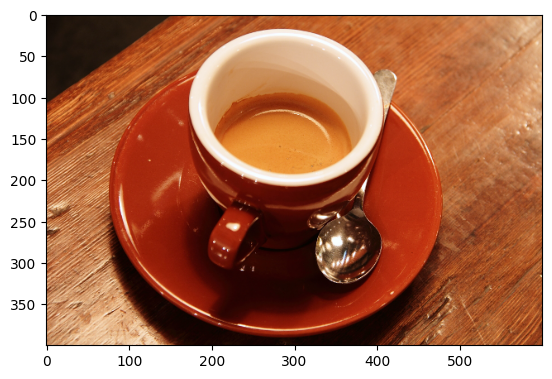

In [36]:


print(img.min(), img.max())
print(img.dtype)

img_norm = img / 255

print(img_norm.min(), img_norm.max())
print(img_norm.dtype)

plt.imshow(img_norm)

<font color='#ff4d00'>Ejercicio: Abrir una imagen RGB y pasarla al espacio de color YIQ, mostrando los 3 canales resultantes</font>

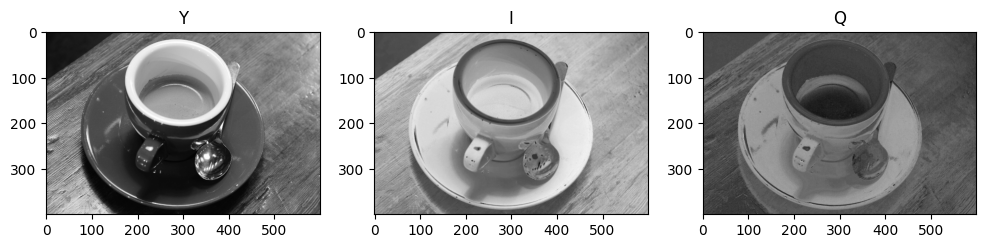

In [37]:
# img_norm
# apply_matrix(img, M)

img_YIQ = apply_matrix(img_norm, MAT_RGB2YIQ)

# plt.imshow(img_YIQ)

Y = img_YIQ[:,:,0]
I = img_YIQ[:,:,1]
Q = img_YIQ[:,:,2]


plt.figure(figsize=(12, 6))

plt.subplot(1, 3, 1)
plt.title('Y')
plt.imshow(Y, cmap="gray")

plt.subplot(1, 3, 2)
plt.title('I')
plt.imshow(I, cmap="gray")

plt.subplot(1, 3, 3)
plt.title('Q')
plt.imshow(Q, cmap="gray")

plt.show()

#Histograma y operaciones sobre luminancia

(array([0., 0., 0., 0., 0., 1., 2., 2., 2., 2.]),
 array([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10.]),
 <BarContainer object of 10 artists>)

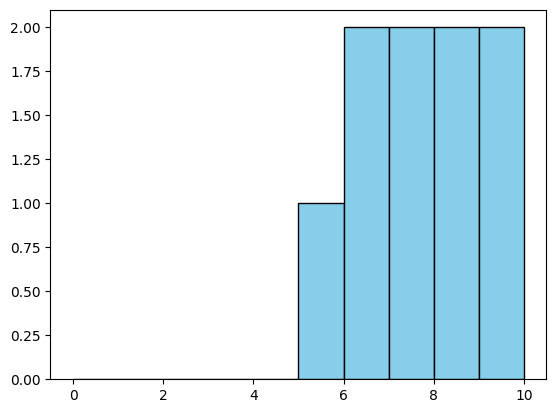

In [38]:
notas = np.array([7, 8, 10, 5, 6, 9, 8, 7, 6])

plt.hist(notas, bins=10, range=(0,10), color='skyblue', edgecolor='black')

En imágenes...

<font color='#ff4d00'>Ejercicio: Mostrar el histograma de luminancia de la imagen anterior.</font>

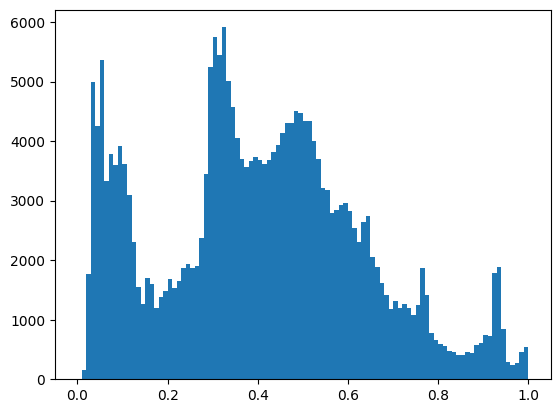

In [40]:
# trabajar con el canal Y, me "olvido" de la crominancia

plt.hist(Y.flatten(), bins=100, range=(0,1))
print()

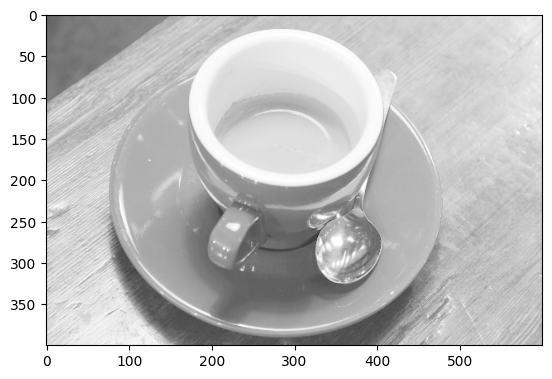

In [43]:
Y_sqrt = np.sqrt(np.sqrt(Y))

plt.imshow(Y_sqrt, 'gray')

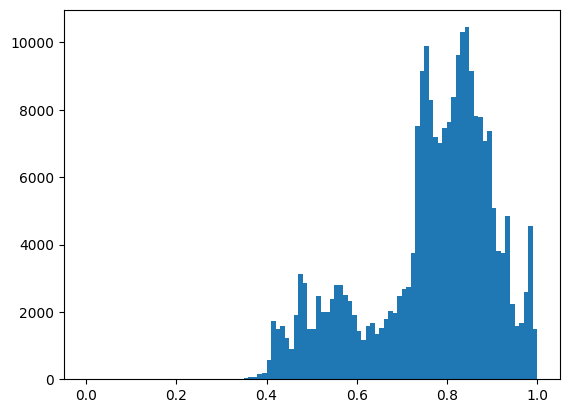

In [45]:
plt.hist(Y_sqrt.flatten(), bins=100, range=(0,1))
print()

(400, 600, 3)
(400, 600, 3)
0.14486807077318622 1.2303631366137087 float64


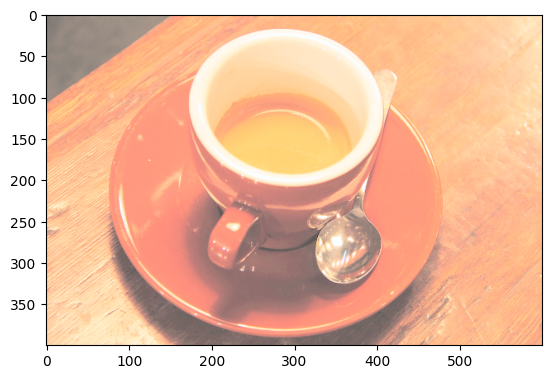

In [54]:
img_YIQ_modificada = np.dstack([Y_sqrt, I, Q])
print(img_YIQ_modificada.shape)

img_rgb_nueva = apply_matrix(img_YIQ_modificada, MAT_YIQ2RGB)
print(img_rgb_nueva.shape)

print(img_rgb_nueva.min(), img_rgb_nueva.max(), img_rgb_nueva.dtype)

plt.imshow(img_rgb_nueva)

<font color='#ff4d00'>Ejercicio: Computar el canal de luminancia de dos imágenes y combinarlos. </font>